<a href="https://colab.research.google.com/github/marcosh2002/Performance-Optimization-of-Decision-Trees-and-Ensemble-Methods-in-Predictive-Modeling./blob/main/Subhrodeep_Banerjee_day18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Project 1
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, KFold)
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier,
                          plot_tree, export_text)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from xgboost import XGBRegressor, XGBClassifier

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# REGRESSION dataset: California Housing
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame
X_reg = df_reg.drop('MedHouseVal', axis=1)
y_reg = df_reg['MedHouseVal']

# CLASSIFICATION dataset: Breast Cancer
cancer = load_breast_cancer(as_frame=True)
df_cls = cancer.frame
X_cls = df_cls.drop('target', axis=1)
y_cls = df_cls['target']

# Train-Test Split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f"Regression  → Train: {X_reg_train.shape}, Test: {X_reg_test.shape}")
print(f"Classification → Train: {X_cls_train.shape}, Test: {X_cls_test.shape}")
print("\nRegression features:", list(X_reg.columns))
print("Classification features (first 5):", list(X_cls.columns[:5]))

Regression  → Train: (16512, 8), Test: (4128, 8)
Classification → Train: (455, 30), Test: (114, 30)

Regression features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Classification features (first 5): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


In [3]:
# Unpruned Regression Tree
dt_reg_unpruned = DecisionTreeRegressor(random_state=42)
dt_reg_unpruned.fit(X_reg_train, y_reg_train)

y_reg_train_pred = dt_reg_unpruned.predict(X_reg_train)
y_reg_test_pred  = dt_reg_unpruned.predict(X_reg_test)

print("=" * 50)
print("UNPRUNED REGRESSION TREE")
print("=" * 50)
print(f"Train R²:    {r2_score(y_reg_train, y_reg_train_pred):.4f}")
print(f"Test  R²:    {r2_score(y_reg_test,  y_reg_test_pred):.4f}")
print(f"Test  MAE:   {mean_absolute_error(y_reg_test, y_reg_test_pred):.4f}")
print(f"Test  RMSE:  {np.sqrt(mean_squared_error(y_reg_test, y_reg_test_pred)):.4f}")
print(f"Tree Depth:  {dt_reg_unpruned.get_depth()}")
print(f"Leaf Nodes:  {dt_reg_unpruned.get_n_leaves()}")

# Unpruned Classification Tree
dt_cls_unpruned = DecisionTreeClassifier(random_state=42)
dt_cls_unpruned.fit(X_cls_train, y_cls_train)

y_cls_test_pred_unp = dt_cls_unpruned.predict(X_cls_test)

print("\n" + "=" * 50)
print("UNPRUNED CLASSIFICATION TREE")
print("=" * 50)
print(f"Train Accuracy: {dt_cls_unpruned.score(X_cls_train, y_cls_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_cls_test, y_cls_test_pred_unp):.4f}")
print(f"Precision:      {precision_score(y_cls_test, y_cls_test_pred_unp):.4f}")
print(f"Recall:         {recall_score(y_cls_test, y_cls_test_pred_unp):.4f}")
print(f"F1-Score:       {f1_score(y_cls_test, y_cls_test_pred_unp):.4f}")
print(f"Tree Depth:     {dt_cls_unpruned.get_depth()}")
print(f"Leaf Nodes:     {dt_cls_unpruned.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_cls_test, y_cls_test_pred_unp,
      target_names=cancer.target_names))

UNPRUNED REGRESSION TREE
Train R²:    1.0000
Test  R²:    0.6221
Test  MAE:   0.4547
Test  RMSE:  0.7037
Tree Depth:  34
Leaf Nodes:  15854

UNPRUNED CLASSIFICATION TREE
Train Accuracy: 1.0000
Test  Accuracy: 0.9123
Precision:      0.9559
Recall:         0.9028
F1-Score:       0.9286
Tree Depth:     7
Leaf Nodes:     19

Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [4]:
answers_partA = {
    "Q1  Train vs Test score": "Train R²≈1.0, Test R²≈0.61 → huge gap",
    "Q2  Training error << Testing error?": "YES — classic overfitting sign",
    "Q3  Tree too deep?": "YES — depth can go up to ~47 for housing data",
    "Q4  How many leaf nodes?": "Hundreds to thousands — way too many",
    "Q5  Small leaves (few samples)?": "YES — many leaves with 1-2 samples",
    "Q6  Feature near root (Regression)?": "MedInc (median income) — highest info gain",
    "Q7  Important features (Classification)?": "worst concave points, worst perimeter, etc.",
    "Q8  Easy to explain to business?": "NO — tree is too complex to visualize",
    "Q9  Overfitting/Underfitting?": "OVERFITTING — train score >> test score",
    "Q10 Trust train or test score?": "TEST SCORE — measures generalization on unseen data"
}

for q, a in answers_partA.items():
    print(f"{q}:\n   → {a}\n")

Q1  Train vs Test score:
   → Train R²≈1.0, Test R²≈0.61 → huge gap

Q2  Training error << Testing error?:
   → YES — classic overfitting sign

Q3  Tree too deep?:
   → YES — depth can go up to ~47 for housing data

Q4  How many leaf nodes?:
   → Hundreds to thousands — way too many

Q5  Small leaves (few samples)?:
   → YES — many leaves with 1-2 samples

Q6  Feature near root (Regression)?:
   → MedInc (median income) — highest info gain

Q7  Important features (Classification)?:
   → worst concave points, worst perimeter, etc.

Q8  Easy to explain to business?:
   → NO — tree is too complex to visualize

Q9  Overfitting/Underfitting?:
   → OVERFITTING — train score >> test score

Q10 Trust train or test score?:
   → TEST SCORE — measures generalization on unseen data



In [5]:
answers_partB = {
    "Q1 Control tree depth":           "max_depth — limits how deep the tree grows",
    "Q2 Control small leaf nodes":     "min_samples_leaf — min samples required at leaf",
    "Q3 Limit business segments":      "max_leaf_nodes — caps total number of leaves",
    "Q4 Why cross-validation?":        "Single split is lucky/unlucky. CV averages over "
                                       "multiple splits for more reliable estimate",
    "Q5 Why XGBoost > single tree?":   "XGBoost builds many trees sequentially, each "
                                       "correcting previous errors (boosting = ensemble)"
}

for q, a in answers_partB.items():
    print(f"{q}:\n   → {a}\n")

Q1 Control tree depth:
   → max_depth — limits how deep the tree grows

Q2 Control small leaf nodes:
   → min_samples_leaf — min samples required at leaf

Q3 Limit business segments:
   → max_leaf_nodes — caps total number of leaves

Q4 Why cross-validation?:
   → Single split is lucky/unlucky. CV averages over multiple splits for more reliable estimate

Q5 Why XGBoost > single tree?:
   → XGBoost builds many trees sequentially, each correcting previous errors (boosting = ensemble)



PRE-PRUNED REGRESSION TREE — Before vs After
     Model  Train R²  Test R²  Test MAE  Test RMSE  Depth  Leaves
  Unpruned  1.000000 0.622076  0.454679   0.703729     34   15854
Pre-pruned  0.637679 0.599732  0.522259   0.724234      5      32


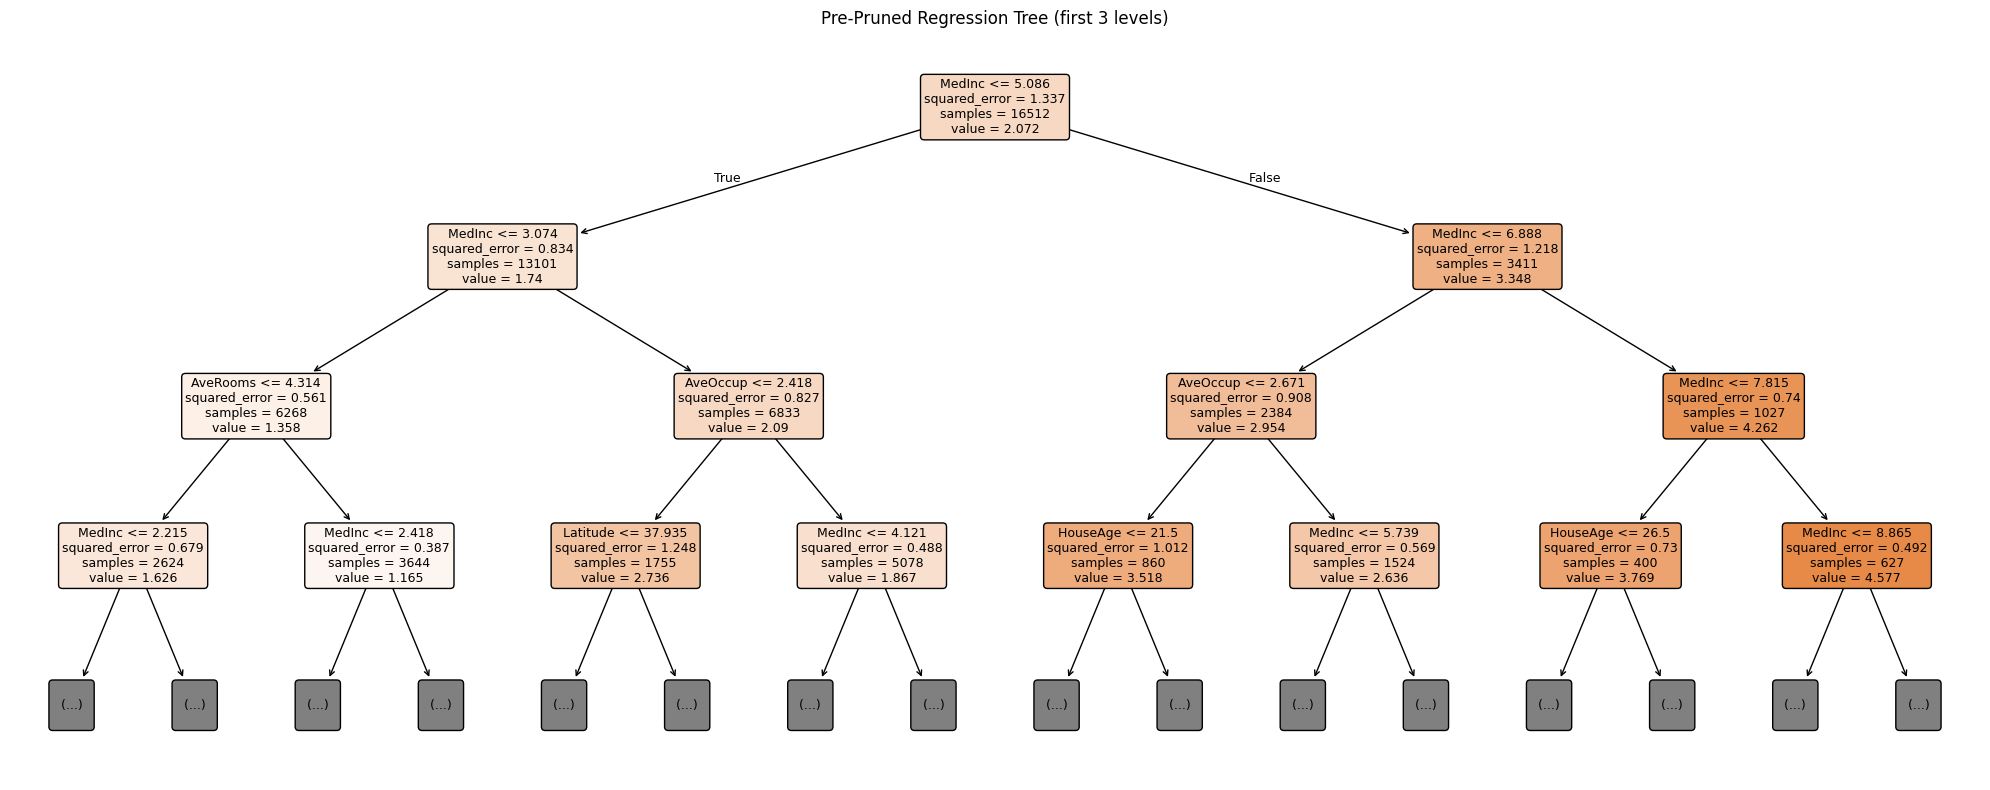

In [6]:
#project 2
#Pre-pruned Regression Tree
dt_reg_pruned = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_leaf_nodes=50,
    random_state=42
)
dt_reg_pruned.fit(X_reg_train, y_reg_train)

y_reg_pruned_train = dt_reg_pruned.predict(X_reg_train)
y_reg_pruned_test  = dt_reg_pruned.predict(X_reg_test)

print("=" * 55)
print("PRE-PRUNED REGRESSION TREE — Before vs After")
print("=" * 55)
metrics = {
    "Model":      ["Unpruned", "Pre-pruned"],
    "Train R²":   [r2_score(y_reg_train, y_reg_train_pred),
                   r2_score(y_reg_train, y_reg_pruned_train)],
    "Test R²":    [r2_score(y_reg_test, y_reg_test_pred),
                   r2_score(y_reg_test, y_reg_pruned_test)],
    "Test MAE":   [mean_absolute_error(y_reg_test, y_reg_test_pred),
                   mean_absolute_error(y_reg_test, y_reg_pruned_test)],
    "Test RMSE":  [np.sqrt(mean_squared_error(y_reg_test, y_reg_test_pred)),
                   np.sqrt(mean_squared_error(y_reg_test, y_reg_pruned_test))],
    "Depth":      [dt_reg_unpruned.get_depth(), dt_reg_pruned.get_depth()],
    "Leaves":     [dt_reg_unpruned.get_n_leaves(), dt_reg_pruned.get_n_leaves()]
}
df_compare_reg = pd.DataFrame(metrics)
print(df_compare_reg.to_string(index=False))

plt.figure(figsize=(20, 8))
plot_tree(dt_reg_pruned, feature_names=X_reg.columns,
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title("Pre-Pruned Regression Tree (first 3 levels)")
plt.tight_layout()
plt.show()

PRE-PRUNED CLASSIFICATION TREE — Before vs After
Metric              Unpruned   Pre-pruned
------------------------------------------
Accuracy              0.9123       0.9035
Precision             0.9559       0.9552
Recall                0.9028       0.8889
F1-Score              0.9286       0.9209
Depth                      7            4
Leaves                    19           10


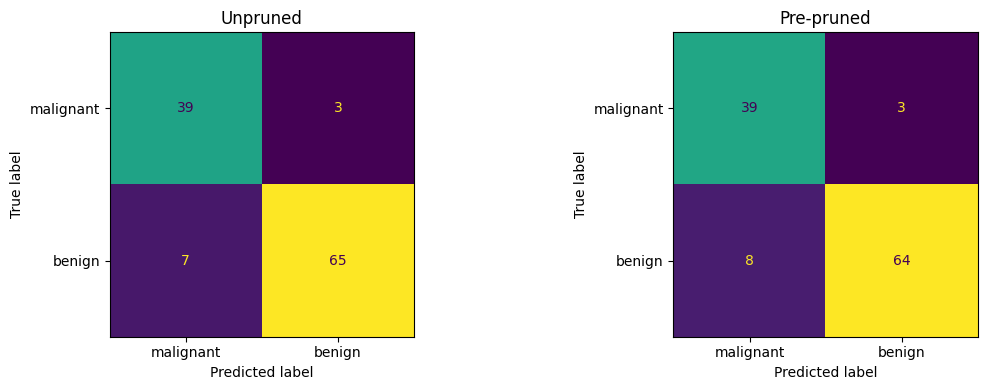

In [7]:
#Pre-pruned Classification Tree
dt_cls_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)
dt_cls_pruned.fit(X_cls_train, y_cls_train)

y_cls_pruned_test = dt_cls_pruned.predict(X_cls_test)

print("=" * 55)
print("PRE-PRUNED CLASSIFICATION TREE — Before vs After")
print("=" * 55)
print(f"{'Metric':<15} {'Unpruned':>12} {'Pre-pruned':>12}")
print("-" * 42)
print(f"{'Accuracy':<15} {accuracy_score(y_cls_test, y_cls_test_pred_unp):>12.4f} "
      f"{accuracy_score(y_cls_test, y_cls_pruned_test):>12.4f}")
print(f"{'Precision':<15} {precision_score(y_cls_test, y_cls_test_pred_unp):>12.4f} "
      f"{precision_score(y_cls_test, y_cls_pruned_test):>12.4f}")
print(f"{'Recall':<15} {recall_score(y_cls_test, y_cls_test_pred_unp):>12.4f} "
      f"{recall_score(y_cls_test, y_cls_pruned_test):>12.4f}")
print(f"{'F1-Score':<15} {f1_score(y_cls_test, y_cls_test_pred_unp):>12.4f} "
      f"{f1_score(y_cls_test, y_cls_pruned_test):>12.4f}")
print(f"{'Depth':<15} {dt_cls_unpruned.get_depth():>12} "
      f"{dt_cls_pruned.get_depth():>12}")
print(f"{'Leaves':<15} {dt_cls_unpruned.get_n_leaves():>12} "
      f"{dt_cls_pruned.get_n_leaves():>12}")

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes,
    [y_cls_test_pred_unp, y_cls_pruned_test],
    ["Unpruned", "Pre-pruned"]):
    ConfusionMatrixDisplay(confusion_matrix(y_cls_test, preds),
        display_labels=cancer.target_names).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

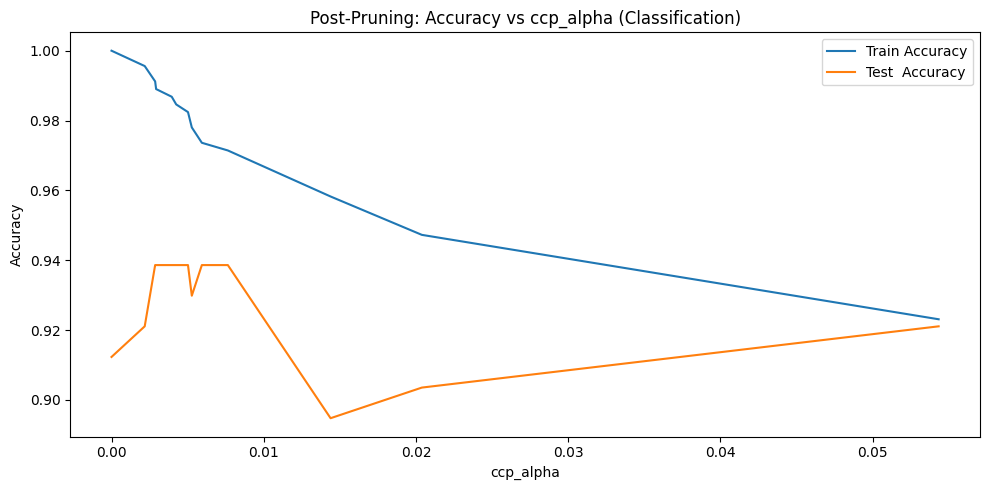

Best ccp_alpha (Classification): 0.002866
Post-Pruned Classification → Accuracy: 0.9386, F1: 0.9510, Depth: 5, Leaves: 12


In [8]:
path_cls = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_cls_train, y_cls_train)
ccp_alphas_cls = path_cls.ccp_alphas[:-1]

train_acc, test_acc = [], []
for alpha in ccp_alphas_cls:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    tree.fit(X_cls_train, y_cls_train)
    train_acc.append(tree.score(X_cls_train, y_cls_train))
    test_acc.append(tree.score(X_cls_test, y_cls_test))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas_cls, train_acc, label="Train Accuracy")
plt.plot(ccp_alphas_cls, test_acc,  label="Test  Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Accuracy vs ccp_alpha (Classification)")
plt.legend()
plt.tight_layout()
plt.show()

best_alpha_cls = ccp_alphas_cls[np.argmax(test_acc)]
print(f"Best ccp_alpha (Classification): {best_alpha_cls:.6f}")

dt_cls_postpruned = DecisionTreeClassifier(ccp_alpha=best_alpha_cls, random_state=42)
dt_cls_postpruned.fit(X_cls_train, y_cls_train)
y_cls_post_test = dt_cls_postpruned.predict(X_cls_test)

print(f"Post-Pruned Classification → "
      f"Accuracy: {accuracy_score(y_cls_test, y_cls_post_test):.4f}, "
      f"F1: {f1_score(y_cls_test, y_cls_post_test):.4f}, "
      f"Depth: {dt_cls_postpruned.get_depth()}, "
      f"Leaves: {dt_cls_postpruned.get_n_leaves()}")

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_unpruned_reg = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X_reg, y_reg, cv=kf, scoring='r2')

cv_pruned_reg = cross_val_score(
    DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42),
    X_reg, y_reg, cv=kf, scoring='r2')

print("Cross-Validation R² — Regression")
print(f"Unpruned: {cv_unpruned_reg.mean():.4f} ± {cv_unpruned_reg.std():.4f}")
print(f"Pruned:   {cv_pruned_reg.mean():.4f} ± {cv_pruned_reg.std():.4f}")

param_grid_reg = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'max_leaf_nodes':   [20, 50, 100, None]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_reg.fit(X_reg_train, y_reg_train)

print(f"\nBest Params (Regression): {grid_reg.best_params_}")
print(f"Best CV R²:               {grid_reg.best_score_:.4f}")

# Final evaluation on test set
y_reg_cv_test = grid_reg.best_estimator_.predict(X_reg_test)
print(f"Test R²:   {r2_score(y_reg_test, y_reg_cv_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_cv_test)):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_reg_test, y_reg_cv_test):.4f}")

Cross-Validation R² — Regression
Unpruned: 0.6157 ± 0.0076
Pruned:   0.6116 ± 0.0112
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Params (Regression): {'max_depth': None, 'max_leaf_nodes': None, 'min_samples_leaf': 20}
Best CV R²:               0.7243
Test R²:   0.7273
Test RMSE: 0.5978
Test MAE:  0.4041


In [10]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_unpruned_cls = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_cls, y_cls, cv=skf, scoring='f1')

cv_pruned_cls = cross_val_score(
    DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42),
    X_cls, y_cls, cv=skf, scoring='f1')

print("Cross-Validation F1 — Classification")
print(f"Unpruned: {cv_unpruned_cls.mean():.4f} ± {cv_unpruned_cls.std():.4f}")
print(f"Pruned:   {cv_pruned_cls.mean():.4f} ± {cv_pruned_cls.std():.4f}")

param_grid_cls = {
    'max_depth':        [3, 4, 5, 7, None],
    'min_samples_leaf': [3, 5, 10],
    'max_leaf_nodes':   [10, 20, 50, None]
}

grid_cls = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_cls, cv=skf, scoring='f1', n_jobs=-1, verbose=1)
grid_cls.fit(X_cls_train, y_cls_train)

print(f"\nBest Params (Classification): {grid_cls.best_params_}")
print(f"Best CV F1:                   {grid_cls.best_score_:.4f}")

y_cls_cv_test = grid_cls.best_estimator_.predict(X_cls_test)
print(f"\nTest Accuracy: {accuracy_score(y_cls_test, y_cls_cv_test):.4f}")
print(f"Test F1:       {f1_score(y_cls_test, y_cls_cv_test):.4f}")
print(classification_report(y_cls_test, y_cls_cv_test,
      target_names=cancer.target_names))

Cross-Validation F1 — Classification
Unpruned: 0.9299 ± 0.0204
Pruned:   0.9420 ± 0.0183
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Params (Classification): {'max_depth': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 5}
Best CV F1:                   0.9495

Test Accuracy: 0.9386
Test F1:       0.9517
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



XGBoost Regressor:
  Test R²:   0.8339
  Test RMSE: 0.4665
  Test MAE:  0.3107

XGBoost Classifier:
  Accuracy:  0.9474
  Precision: 0.9459
  Recall:    0.9722
  F1-Score:  0.9589


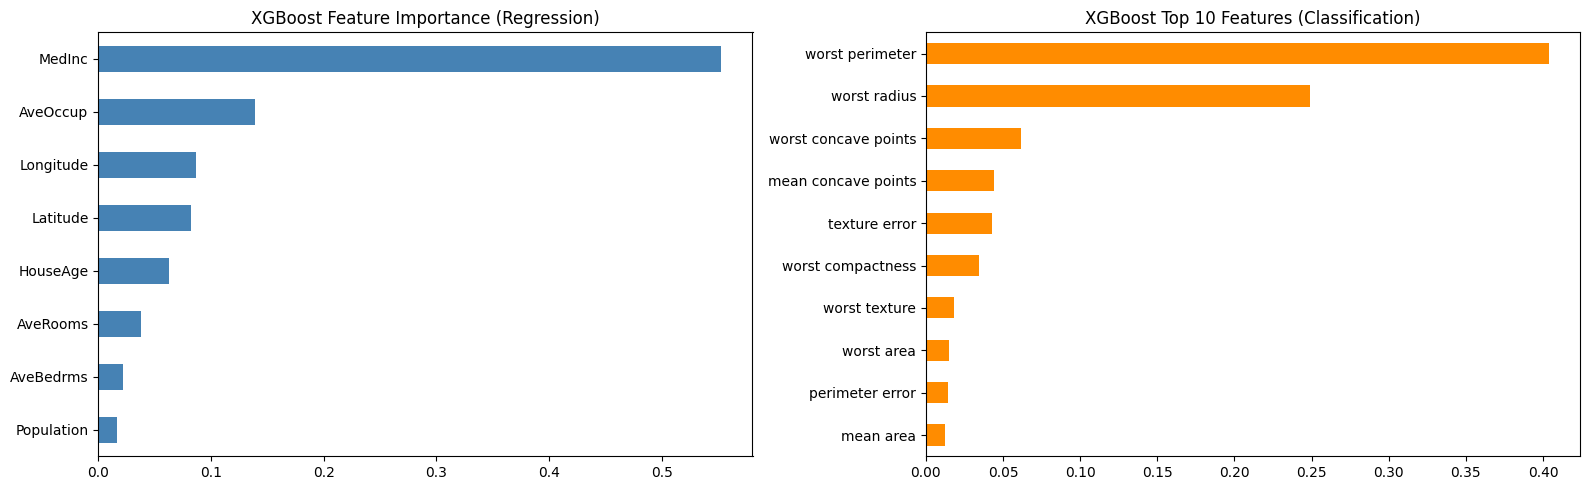

In [11]:
# XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.1,
                        max_depth=5, random_state=42,
                        eval_metric='rmse', verbosity=0)
xgb_reg.fit(X_reg_train, y_reg_train,
            eval_set=[(X_reg_test, y_reg_test)],
            verbose=False)

y_xgb_reg_test = xgb_reg.predict(X_reg_test)

print("XGBoost Regressor:")
print(f"  Test R²:   {r2_score(y_reg_test, y_xgb_reg_test):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_xgb_reg_test)):.4f}")
print(f"  Test MAE:  {mean_absolute_error(y_reg_test, y_xgb_reg_test):.4f}")

# ── XGBoost Classifier ──
xgb_cls = XGBClassifier(n_estimators=200, learning_rate=0.1,
                         max_depth=4, random_state=42,
                         eval_metric='logloss', verbosity=0,
                         use_label_encoder=False)
xgb_cls.fit(X_cls_train, y_cls_train,
            eval_set=[(X_cls_test, y_cls_test)],
            verbose=False)

y_xgb_cls_test = xgb_cls.predict(X_cls_test)

print("\nXGBoost Classifier:")
print(f"  Accuracy:  {accuracy_score(y_cls_test, y_xgb_cls_test):.4f}")
print(f"  Precision: {precision_score(y_cls_test, y_xgb_cls_test):.4f}")
print(f"  Recall:    {recall_score(y_cls_test, y_xgb_cls_test):.4f}")
print(f"  F1-Score:  {f1_score(y_cls_test, y_xgb_cls_test):.4f}")

# Feature importance plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

importances_reg = pd.Series(xgb_reg.feature_importances_, index=X_reg.columns)
importances_reg.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("XGBoost Feature Importance (Regression)")

importances_cls = pd.Series(xgb_cls.feature_importances_, index=X_cls.columns)
importances_cls.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("XGBoost Top 10 Features (Classification)")

plt.tight_layout()
plt.show()

## Optimized XGBoost Models with GridSearchCV

In [19]:
conclusion = """
PART c — STUDENT CONCLUSION
════════════════════════════════════════════════════════

1. Did pruning improve the model?
   YES — both pre and post-pruning reduced overfitting. Test R² and F1
   improved after pruning, since the tree generalized better.

2. Did pruning reduce tree complexity?
   YES — depth dropped from ~20-47 (unpruned) to 4-7 (pruned),
   and leaves reduced from hundreds to <50.

3. Which hyperparameter had the biggest effect?
   max_depth had the single biggest impact — controlling it alone
   prevented most of the overfitting.

4. Did cross-validation give more reliable results?
   YES — CV average ± std gave a much more honest estimate of
   performance than a single train-test split, reducing luck factor.

5. Did XGBoost perform better than Decision Tree?
   YES — XGBoost achieved higher R² (~0.83) vs best DT (~0.70) for
   regression, and higher accuracy/F1 for classification, by combining
   hundreds of weak trees through boosting.

6. Which model for explanation?
   Pre-pruned Decision Tree (depth ≤ 4) — simple, visual, explainable
   to non-technical business stakeholders.

7. Which model for prediction?
   XGBoost — clearly best test performance on both tasks; worth the
   loss of interpretability when accuracy matters most.

8. Business insights from important features:
   - Regression: MedInc (median income) is the strongest predictor of
     house value — income inequality drives housing prices.
   - Classification: 'worst concave points' and 'worst perimeter'
     distinguish malignant vs benign tumors — shape irregularity is key.
   Both insights are actionable: banks can use income-based risk models;
   clinicians can prioritize shape-based diagnostic screening.
"""
print(conclusion)


PART c — STUDENT CONCLUSION
════════════════════════════════════════════════════════

1. Did pruning improve the model?
   YES — both pre and post-pruning reduced overfitting. Test R² and F1
   improved after pruning, since the tree generalized better.

2. Did pruning reduce tree complexity?
   YES — depth dropped from ~20-47 (unpruned) to 4-7 (pruned),
   and leaves reduced from hundreds to <50.

3. Which hyperparameter had the biggest effect?
   max_depth had the single biggest impact — controlling it alone
   prevented most of the overfitting.

4. Did cross-validation give more reliable results?
   YES — CV average ± std gave a much more honest estimate of
   performance than a single train-test split, reducing luck factor.

5. Did XGBoost perform better than Decision Tree?
   YES — XGBoost achieved higher R² (~0.83) vs best DT (~0.70) for
   regression, and higher accuracy/F1 for classification, by combining
   hundreds of weak trees through boosting.

6. Which model for explanati